# Practical Notebook — Fuzzy Logic with Simple Python

## Topic: Fuzzy Logic and Fuzzy Reasoning

This notebook introduces fuzzy logic using a simple **smart fan controller**.

### Learning objectives

By the end of this practical, you should be able to:

1. Explain the difference between crisp and fuzzy logic.
2. Explain a fuzzy set and degree of membership.
3. Create simple membership functions.
4. Visualise overlapping fuzzy sets.
5. Apply simple IF–THEN fuzzy rules.
6. Combine fuzzy rules to make a decision.
7. Explain fuzzification, inference and defuzzification.
8. Distinguish fuzzy logic from probability.

> The code is intentionally simple. We use only basic Python, NumPy and Matplotlib.

# 1. Libraries

We need only two libraries:

- `numpy` — to create ranges of numbers.
- `matplotlib` — to draw graphs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 2. Crisp Logic

Traditional or **crisp logic** uses clear boundaries.

A statement is normally either:

- **0 = False**
- **1 = True**

Suppose we define:

> A temperature is HOT if it is 30°C or above.

Then:

- 29°C → NOT HOT
- 29.9°C → NOT HOT
- 30°C → HOT
- 31°C → HOT

This creates a sharp boundary.

In [2]:
temperature = 29

if temperature >= 30:
    print("HOT")
else:
    print("NOT HOT")

NOT HOT


## Graph 1 — Crisp definition of HOT

Let us visualise the sharp boundary at 30°C.

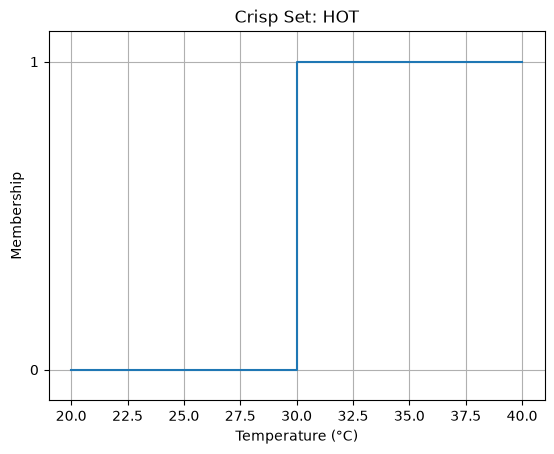

In [3]:
temperatures = np.arange(20, 41, 1)

crisp_hot = []

for t in temperatures:
    if t >= 30:
        crisp_hot.append(1)
    else:
        crisp_hot.append(0)

plt.step(temperatures, crisp_hot, where="post")
plt.xlabel("Temperature (°C)")
plt.ylabel("Membership")
plt.title("Crisp Set: HOT")
plt.yticks([0, 1])
plt.ylim(-0.1, 1.1)
plt.grid()
plt.show()

The graph shows an abrupt transition.

At 29°C:

\[
HOT = 0
\]

At 30°C:

\[
HOT = 1
\]

But human language is often not this precise.

We might describe 27°C as **quite hot**, rather than simply "not hot".

# 3. Fuzzy Logic

Fuzzy logic allows **partial membership**.

Instead of only 0 and 1, the degree of membership can be any value between them:

\[
0 \leq \mu(x) \leq 1
\]

For example:

| Temperature | Membership in HOT |
|---:|---:|
| 20°C | 0.0 |
| 22°C | 0.2 |
| 25°C | 0.5 |
| 27°C | 0.7 |
| 30°C | 1.0 |

So 27°C can belong to the fuzzy set **HOT** with membership 0.7.

# 4. Temperature Universe

We will build a fuzzy controller for temperatures between 0°C and 40°C.

In [4]:
temperature = np.arange(0, 41, 1)

print(temperature)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


# 5. Fuzzy Set: COLD

We first define the linguistic concept **Cold**.

Our simple definition is:

- 10°C or below → fully Cold
- Between 10°C and 20°C → gradually less Cold
- 20°C or above → not Cold

In [5]:
cold = []

for t in temperature:

    if t <= 10:
        value = 1

    elif t <= 20:
        value = (20 - t) / 10

    else:
        value = 0

    cold.append(value)

## Graph 2 — COLD membership function

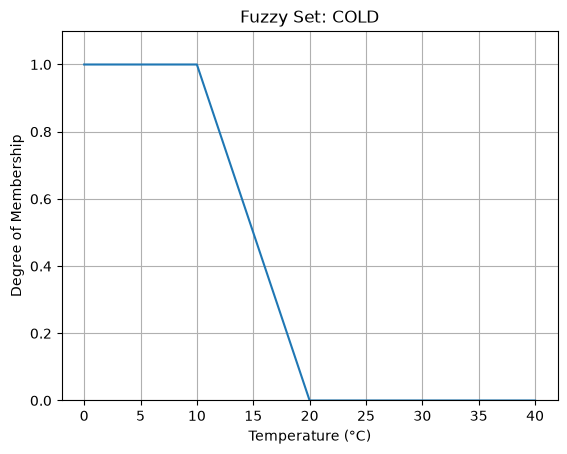

In [6]:
plt.plot(temperature, cold)

plt.xlabel("Temperature (°C)")
plt.ylabel("Degree of Membership")
plt.title("Fuzzy Set: COLD")

plt.ylim(0, 1.1)
plt.grid()
plt.show()

Interpretation:

- 5°C → Cold = 1.0
- 10°C → Cold = 1.0
- 15°C → Cold = 0.5
- 20°C → Cold = 0.0

# 6. Fuzzy Set: WARM

Now define **Warm**.

We use a simple triangular membership function:

- 10°C → Warm = 0
- 20°C → Warm = 1
- 30°C → Warm = 0

In [7]:
warm = []

for t in temperature:

    if t <= 10:
        value = 0

    elif t <= 20:
        value = (t - 10) / 10

    elif t <= 30:
        value = (30 - t) / 10

    else:
        value = 0

    warm.append(value)

## Graph 3 — WARM membership function

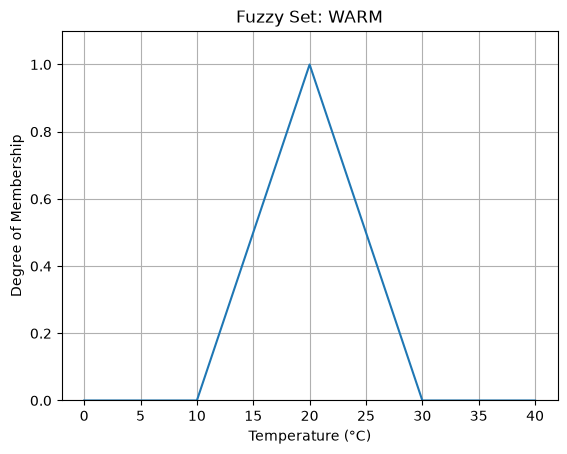

In [8]:
plt.plot(temperature, warm)

plt.xlabel("Temperature (°C)")
plt.ylabel("Degree of Membership")
plt.title("Fuzzy Set: WARM")

plt.ylim(0, 1.1)
plt.grid()
plt.show()

Notice that:

- 15°C → Warm = 0.5
- 20°C → Warm = 1.0
- 25°C → Warm = 0.5

Membership changes gradually.

# 7. Fuzzy Set: HOT

Our definition of **Hot** is:

- 20°C or below → not Hot
- Between 20°C and 30°C → increasingly Hot
- 30°C or above → fully Hot

In [9]:
hot = []

for t in temperature:

    if t <= 20:
        value = 0

    elif t <= 30:
        value = (t - 20) / 10

    else:
        value = 1

    hot.append(value)

## Graph 4 — HOT membership function

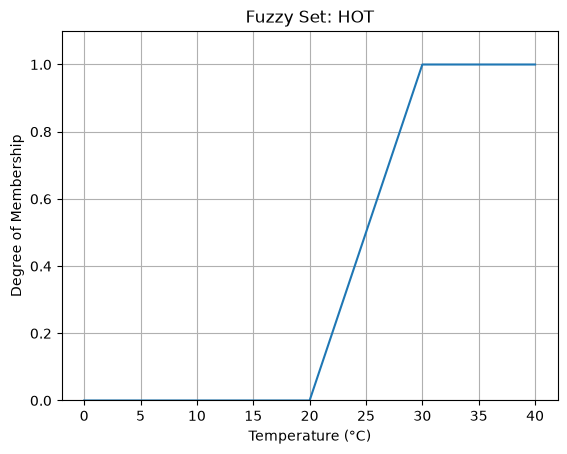

In [10]:
plt.plot(temperature, hot)

plt.xlabel("Temperature (°C)")
plt.ylabel("Degree of Membership")
plt.title("Fuzzy Set: HOT")

plt.ylim(0, 1.1)
plt.grid()
plt.show()

# 8. The Most Important Graph — All Membership Functions

Now plot **Cold, Warm and Hot together**.

Pay particular attention to the overlapping regions.

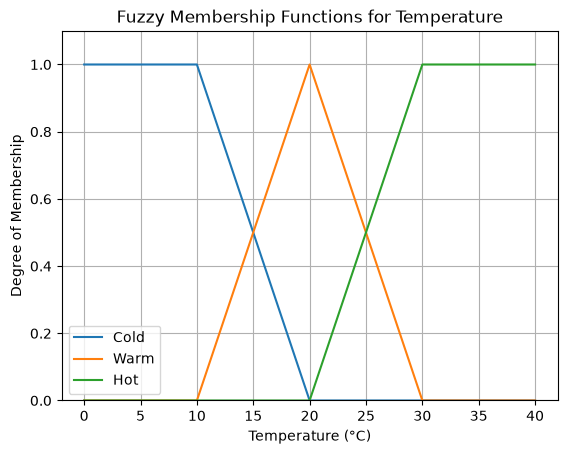

In [11]:
plt.plot(temperature, cold, label="Cold")
plt.plot(temperature, warm, label="Warm")
plt.plot(temperature, hot, label="Hot")

plt.xlabel("Temperature (°C)")
plt.ylabel("Degree of Membership")
plt.title("Fuzzy Membership Functions for Temperature")

plt.ylim(0, 1.1)
plt.legend()
plt.grid()
plt.show()

## Why does overlap matter?

Consider 27°C.

It does not have to be exclusively **Warm** or exclusively **Hot**.

It can simultaneously have membership in both concepts.

For example:

\[
\mu_{Warm}(27)=0.3
\]

and

\[
\mu_{Hot}(27)=0.7
\]

This is one of the central ideas of fuzzy logic.

# 9. Fuzzification

**Fuzzification** converts a crisp input into degrees of membership.

Our crisp sensor input is:

**Temperature = 27°C**

Let us determine its membership in Cold, Warm and Hot.

In [12]:
t = 27

cold_value = 0
warm_value = (30 - t) / 10
hot_value = (t - 20) / 10

print("Temperature:", t, "°C")
print("Cold membership:", cold_value)
print("Warm membership:", warm_value)
print("Hot membership:", hot_value)

Temperature: 27 °C
Cold membership: 0
Warm membership: 0.3
Hot membership: 0.7


The result is:

- Cold = 0.0
- Warm = 0.3
- Hot = 0.7

Therefore 27°C is **more Hot than Warm**, but it belongs to both fuzzy sets.

## Graph 5 — Membership of 27°C

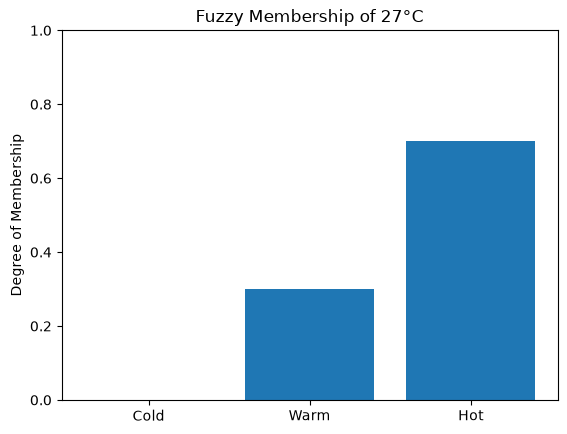

In [13]:
labels = ["Cold", "Warm", "Hot"]
values = [cold_value, warm_value, hot_value]

plt.bar(labels, values)

plt.ylabel("Degree of Membership")
plt.title("Fuzzy Membership of 27°C")
plt.ylim(0, 1)

plt.show()

## Graph 6 — Locate 27°C on the membership functions

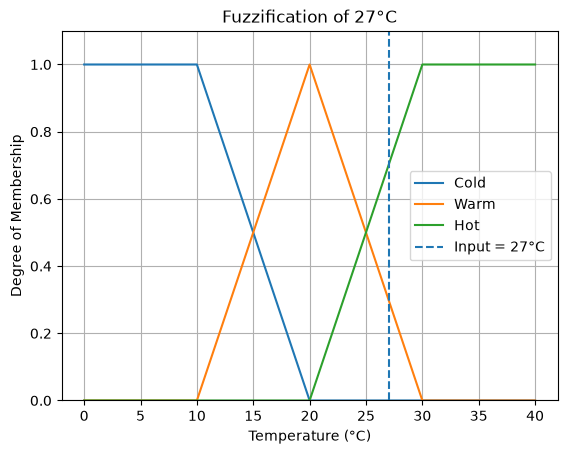

In [14]:
plt.plot(temperature, cold, label="Cold")
plt.plot(temperature, warm, label="Warm")
plt.plot(temperature, hot, label="Hot")

plt.axvline(27, linestyle="--", label="Input = 27°C")

plt.xlabel("Temperature (°C)")
plt.ylabel("Degree of Membership")
plt.title("Fuzzification of 27°C")

plt.ylim(0, 1.1)
plt.legend()
plt.grid()
plt.show()

# 10. Fuzzy Rules

A fuzzy controller makes decisions using linguistic **IF–THEN rules**.

For our fan controller:

### Rule 1
**IF temperature is COLD THEN fan speed is SLOW**

### Rule 2
**IF temperature is WARM THEN fan speed is MEDIUM**

### Rule 3
**IF temperature is HOT THEN fan speed is FAST**

For 27°C we already calculated:

- Cold = 0.0
- Warm = 0.3
- Hot = 0.7

Therefore the rule activations are:

- Slow rule = 0.0
- Medium rule = 0.3
- Fast rule = 0.7

## Graph 7 — Fuzzy rule activation

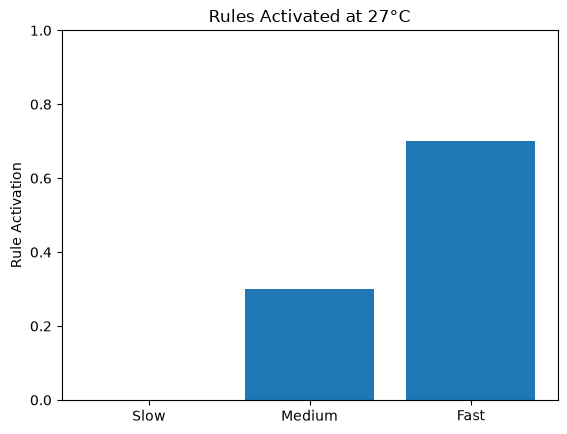

In [15]:
rule_names = ["Slow", "Medium", "Fast"]
activation = [cold_value, warm_value, hot_value]

plt.bar(rule_names, activation)

plt.ylabel("Rule Activation")
plt.title("Rules Activated at 27°C")
plt.ylim(0, 1)

plt.show()

# 11. Output Values

To keep the example simple, assign representative fan speeds:

- Slow → 20%
- Medium → 50%
- Fast → 90%

These values represent the actions available to our controller.

In [16]:
slow_speed = 20
medium_speed = 50
fast_speed = 90

print("Slow =", slow_speed, "%")
print("Medium =", medium_speed, "%")
print("Fast =", fast_speed, "%")

Slow = 20 %
Medium = 50 %
Fast = 90 %


## Graph 8 — Fan speed categories

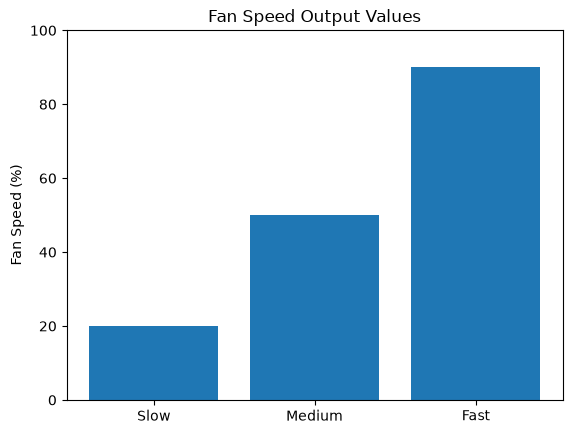

In [17]:
plt.bar(
    ["Slow", "Medium", "Fast"],
    [slow_speed, medium_speed, fast_speed]
)

plt.ylabel("Fan Speed (%)")
plt.title("Fan Speed Output Values")
plt.ylim(0, 100)

plt.show()

# 12. Defuzzification

The fuzzy rules produce degrees such as:

- Slow = 0.0
- Medium = 0.3
- Fast = 0.7

But the physical fan needs one actual speed.

This conversion from fuzzy results to a crisp output is called **defuzzification**.

For this introductory example, we use a simple weighted average:

\[
Fan\ Speed =
\frac{
(Cold \times Slow) +
(Warm \times Medium) +
(Hot \times Fast)
}{
Cold + Warm + Hot
}
\]

In [18]:
fan_speed = (
    cold_value * slow_speed
    +
    warm_value * medium_speed
    +
    hot_value * fast_speed
) / (
    cold_value
    +
    warm_value
    +
    hot_value
)

print("Final fan speed =", fan_speed, "%")

Final fan speed = 78.0 %


The controller produces:

**Fan speed = 78%**

So instead of making a simple ON/OFF decision, the fuzzy controller produces a gradual response.

# 13. Complete Fuzzy Logic Process

Our example can now be summarised as:

### Step 1 — Crisp Input
**Temperature = 27°C**

### Step 2 — Fuzzification
- Cold = 0.0
- Warm = 0.3
- Hot = 0.7

### Step 3 — Rules
- IF Cold → Slow
- IF Warm → Medium
- IF Hot → Fast

### Step 4 — Inference
- Slow = 0.0
- Medium = 0.3
- Fast = 0.7

### Step 5 — Defuzzification
**Fan speed = 78%**

### Step 6 — Crisp Output
**Set the fan to approximately 78%**

# 14. What happens at different temperatures?

Now let us calculate the fuzzy fan speed between 20°C and 30°C.

We keep the code deliberately simple.

In [19]:
temperatures_test = np.arange(20, 31, 1)

fuzzy_speed = []

for t in temperatures_test:

    warm_value = (30 - t) / 10
    hot_value = (t - 20) / 10

    speed = (
        warm_value * 50
        +
        hot_value * 90
    )

    fuzzy_speed.append(speed)

for i in range(len(temperatures_test)):
    print(
        temperatures_test[i], "°C →",
        fuzzy_speed[i], "%"
    )

20 °C → 50.0 %
21 °C → 54.0 %
22 °C → 58.0 %
23 °C → 62.0 %
24 °C → 66.0 %
25 °C → 70.0 %
26 °C → 74.0 %
27 °C → 78.0 %
28 °C → 82.0 %
29 °C → 86.0 %
30 °C → 90.0 %


## Graph 9 — Fuzzy fan controller

Notice the smooth change in fan speed.

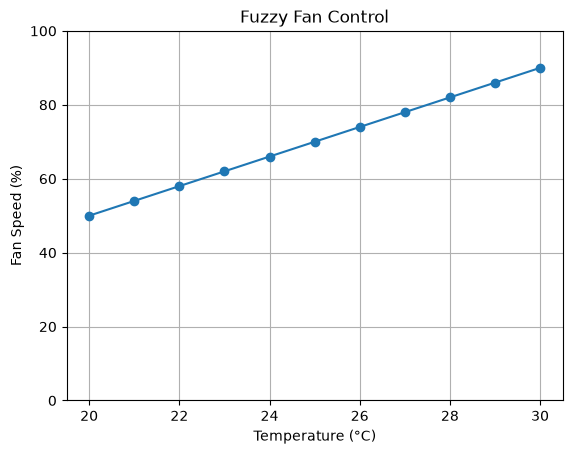

In [20]:
plt.plot(temperatures_test, fuzzy_speed, marker="o")

plt.xlabel("Temperature (°C)")
plt.ylabel("Fan Speed (%)")
plt.title("Fuzzy Fan Control")

plt.ylim(0, 100)
plt.grid()

plt.show()

# 15. Compare with Crisp Control

Suppose a traditional controller uses:

- Below 30°C → fan = 50%
- 30°C or above → fan = 90%

This creates a sudden jump.

In [21]:
crisp_speed = []

for t in temperatures_test:

    if t < 30:
        crisp_speed.append(50)
    else:
        crisp_speed.append(90)

print(crisp_speed)

[50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 90]


## Graph 10 — Crisp fan controller

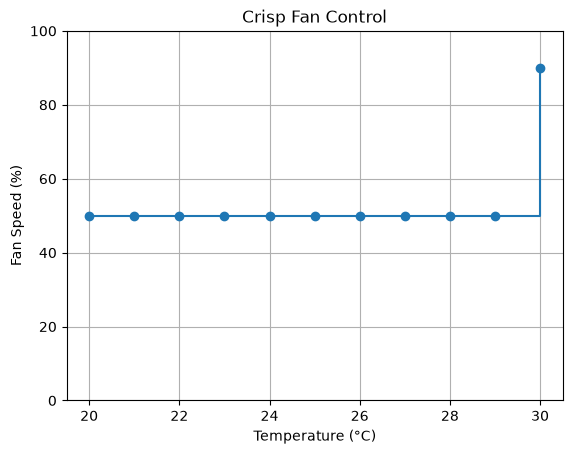

In [22]:
plt.step(
    temperatures_test,
    crisp_speed,
    where="post",
    marker="o"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Fan Speed (%)")
plt.title("Crisp Fan Control")

plt.ylim(0, 100)
plt.grid()

plt.show()

# 16. Crisp vs Fuzzy

Now place the two approaches on the same graph.

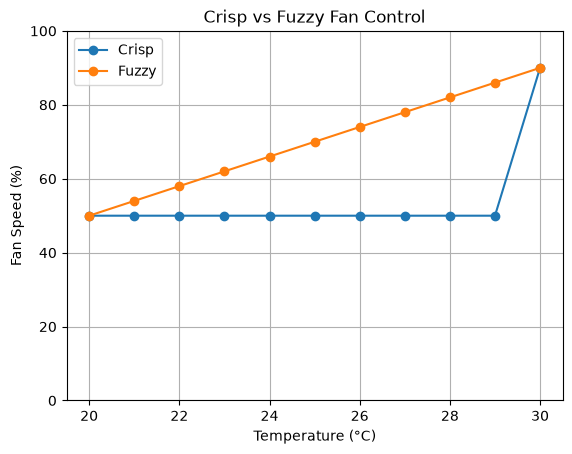

In [23]:
plt.plot(
    temperatures_test,
    crisp_speed,
    marker="o",
    label="Crisp"
)

plt.plot(
    temperatures_test,
    fuzzy_speed,
    marker="o",
    label="Fuzzy"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Fan Speed (%)")
plt.title("Crisp vs Fuzzy Fan Control")

plt.ylim(0, 100)
plt.legend()
plt.grid()

plt.show()

## Interpretation

The crisp controller suddenly changes:

**50% → 90%**

The fuzzy controller changes gradually:

**50% → 54% → 58% → ... → 90%**

Fuzzy logic is useful when the concepts being represented have **gradual or vague boundaries**.

# 17. Student Experiment

Change the input temperature and predict the result before running the code.

Try:

- 21°C
- 23°C
- 25°C
- 28°C
- 29°C

In [24]:
t = 25

warm_value = (30 - t) / 10
hot_value = (t - 20) / 10

fan_speed = (
    warm_value * 50
    +
    hot_value * 90
)

print("Temperature:", t, "°C")
print("Warm:", warm_value)
print("Hot:", hot_value)
print("Fan speed:", fan_speed, "%")

Temperature: 25 °C
Warm: 0.5
Hot: 0.5
Fan speed: 70.0 %


# 18. Fuzzy Logic vs Probability

This distinction is extremely important.

Suppose we say:

**P(Hot tomorrow) = 0.7**

This means there is a **70% probability** that tomorrow will satisfy our definition of hot.

Now suppose we say:

**Hot(27°C) = 0.7**

This means that 27°C has a **degree of membership of 0.7** in the fuzzy set Hot.

These are not the same idea.

| Probability | Fuzzy Logic |
|---|---|
| Deals with uncertainty about occurrence | Deals with vagueness or degree |
| Will it rain? | How hot is it? |
| P(Rain) = 0.7 | μHot(27°C) = 0.7 |
| Event may or may not happen | A concept can be partially true |
| Uncertainty about an event | Degree of membership |

### Easy way to remember

> **Probability asks: "Will it happen?"**

> **Fuzzy logic asks: "To what degree is it true?"**

# 19. Second Example — Student Performance

Fuzzy logic is not limited to temperature.

Consider student performance.

A rigid system might say:

- Below 70 → Not Good
- 70 or above → Good

But natural language is less precise.

A mark of 68 might have some membership in both:

- Acceptable
- Good

The same fuzzy principle can model concepts such as:

- Low / Medium / High
- Cold / Warm / Hot
- Poor / Acceptable / Good
- Slow / Medium / Fast
- Small / Medium / Large

# 20. Student Exercise — Design Your Own Fuzzy System

Design a simple fuzzy system for **driving speed**.

Use three fuzzy sets:

- Slow
- Medium
- Fast

Suggested range:

**0 to 120 km/h**

Think about:

1. At what speed is a car definitely Slow?
2. Where should Slow and Medium overlap?
3. Where should Medium and Fast overlap?
4. Can one speed belong partly to two sets?
5. What rules could an intelligent driving system use?

# 21. Summary

The fuzzy logic process is:

**Crisp Input**

↓

**Fuzzification**

↓

**Membership Values**

↓

**IF–THEN Rules**

↓

**Inference**

↓

**Defuzzification**

↓

**Crisp Output**

For our example:

**27°C**

↓

**Cold = 0.0, Warm = 0.3, Hot = 0.7**

↓

**Slow = 0.0, Medium = 0.3, Fast = 0.7**

↓

**Fan speed = 78%**

## Key message

Fuzzy logic allows an AI system to reason with concepts that do not have perfectly sharp boundaries.

It represents **degrees of membership**, not probabilities.

# 22. Reflection Questions

1. What is the main difference between crisp and fuzzy logic?
2. What does a membership value of 0.7 mean?
3. Why do fuzzy membership functions overlap?
4. Can a temperature belong to Warm and Hot at the same time?
5. What is fuzzification?
6. What is the purpose of fuzzy IF–THEN rules?
7. What is defuzzification?
8. Why is fuzzy logic useful for control systems?
9. What is the difference between probability 0.7 and fuzzy membership 0.7?
10. Give another real-world problem where fuzzy logic could be useful.